<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_6/enc_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encontros 5–6: Estatística Descritiva e Visualização com SciPy, Seaborn e Matplotlib

**Instrutor**: Jhonatan Lopes

> Este notebook começa retomando as células finais do Encontro 5, para que possa ser executado de forma independente. O conteúdo específico do Encontro 6 começa na seção indicada abaixo.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [2]:
arxiv_url = (
    "https://raw.githubusercontent.com/jhlopesalves/"
    "eda_humanidades/refs/heads/main/"
    "encontro_5/data/arxiv_eda_papers.csv"
)

arxiv_df = pd.read_csv(
    arxiv_url,
    dtype={"paper_id": "string"},
)

In [3]:
arxiv_df.head()

,paper_id,title,abstract_preview,primary_category,category_label,top_level,top_level_label,year,decade,n_authors,n_versions,n_categories,title_n_words,abstract_n_words,has_doi,has_journal_ref
0,2001.04171,Multi-Sensor Data and Knowledge Fusion -- A Pr...,Fusion is a common tool for the analysis and u...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,2,1,3,12,108,False,False
1,2001.04417,Maximal Closed Set and Half-Space Separations ...,Several concept learning problems can be regar...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,3,3,2,10,170,False,False
2,2002.00509,A Machine Consciousness architecture based on ...,Recent developments in machine learning have p...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,2,2,1,11,197,False,False
3,2003.03875,Overview of the CCKS 2019 Knowledge Graph Eval...,Knowledge graph models world knowledge as conc...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,25,1,2,14,92,False,False
4,2003.06492,On Sufficient and Necessary Conditions in Boun...,Computation Tree Logic (CTL) is one of the cen...,cs.AI,Artificial Intelligence,cs,Computer Science,2020,2020s,5,3,2,11,203,False,False


In [4]:
arxiv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   paper_id          3387 non-null   string
 1   title             3387 non-null   str   
 2   abstract_preview  3387 non-null   str   
 3   primary_category  3387 non-null   str   
 4   category_label    3387 non-null   str   
 5   top_level         3387 non-null   str   
 6   top_level_label   3387 non-null   str   
 7   year              3387 non-null   int64 
 8   decade            3387 non-null   str   
 9   n_authors         3387 non-null   int64 
 10  n_versions        3387 non-null   int64 
 11  n_categories      3387 non-null   int64 
 12  title_n_words     3387 non-null   int64 
 13  abstract_n_words  3387 non-null   int64 
 14  has_doi           3387 non-null   bool  
 15  has_journal_ref   3387 non-null   bool  
dtypes: bool(2), int64(6), str(7), string(1)
memory usage: 377.2 KB


In [5]:
arxiv_df.describe()

,year,n_authors,n_versions,n_categories,title_n_words,abstract_n_words
count,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000
mean,2022.854739,4.202834,1.695010,2.184529,9.912902,172.085326
std,1.732267,4.305577,0.992284,1.113424,3.524000,47.876997
min,2020.000000,1.000000,1.000000,1.000000,2.000000,38.000000
25%,2021.000000,2.000000,1.000000,1.000000,7.000000,139.000000
50%,2023.000000,4.000000,1.000000,2.000000,10.000000,171.000000
75%,2024.000000,5.000000,2.000000,3.000000,12.000000,204.000000
max,2025.000000,182.000000,8.000000,8.000000,32.000000,310.000000


In [6]:
arxiv_df = arxiv_df.astype(
    {
        "title": "string",
        "abstract_preview": "string",
        "primary_category": "category",
        "category_label": "category",
        "top_level": "category",
        "top_level_label": "category",
        "decade": "category",
        "has_doi": "bool",
        "has_journal_ref": "bool",
    }
)

arxiv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   paper_id          3387 non-null   string  
 1   title             3387 non-null   string  
 2   abstract_preview  3387 non-null   string  
 3   primary_category  3387 non-null   category
 4   category_label    3387 non-null   category
 5   top_level         3387 non-null   category
 6   top_level_label   3387 non-null   category
 7   year              3387 non-null   int64   
 8   decade            3387 non-null   category
 9   n_authors         3387 non-null   int64   
 10  n_versions        3387 non-null   int64   
 11  n_categories      3387 non-null   int64   
 12  title_n_words     3387 non-null   int64   
 13  abstract_n_words  3387 non-null   int64   
 14  has_doi           3387 non-null   bool    
 15  has_journal_ref   3387 non-null   bool    
dtypes: bool(2), category(5), int64(6), 

In [7]:
arxiv_df.describe()

,year,n_authors,n_versions,n_categories,title_n_words,abstract_n_words
count,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000,3387.000000
mean,2022.854739,4.202834,1.695010,2.184529,9.912902,172.085326
std,1.732267,4.305577,0.992284,1.113424,3.524000,47.876997
min,2020.000000,1.000000,1.000000,1.000000,2.000000,38.000000
25%,2021.000000,2.000000,1.000000,1.000000,7.000000,139.000000
50%,2023.000000,4.000000,1.000000,2.000000,10.000000,171.000000
75%,2024.000000,5.000000,2.000000,3.000000,12.000000,204.000000
max,2025.000000,182.000000,8.000000,8.000000,32.000000,310.000000


## `n_categories`

In [8]:
arxiv_df["n_categories"].describe()

count    3387.000000
mean        2.184529
std         1.113424
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: n_categories, dtype: float64

## Toda medida de centro ou comparação precisa vir acompanhada de alguma noção de variação, dispersão ou incerteza.

- qual é o centro?
- quanta variação existe?
- a distribuição é simétrica ou assimétrica?
- há valores extremos?
- o gráfico confirma ou complica o resumo numérico?

### Standard Deviation (desvio padrão)

**Fórmula (Amostral):**
$$ s = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}} $$

**Onde:**
*   $s$ é o desvio padrão amostral.
*   $x_i$ representa cada valor individual no conjunto de dados.
*   $\bar{x}$ é a média aritmética dos valores.
*   $n$ é o número total de observações na amostra.

**DESVIO PADRÃO EM SLOW-MOTION - INVESTIGANDO FÓRMULAS!**

In [43]:
values = arxiv_df["n_categories"]

x_bar = values.mean()
n = len(values)

sum_of_squared_deviations = np.sum(
    [
        (x_i - x_bar)
        ** 2  # Correção: parênteses ao redor da subtração antes de elevar ao quadrado
        for x_i in values  # O loop que passa por cada valor
    ]
)

# Dividir por (n-1) para obter a variância amostral
sample_variance = sum_of_squared_deviations / (n - 1)

# Tirar a raiz quadrada da variância para obter o desvio padrão
sample_standard_deviation = np.sqrt(sample_variance)

print(f"Média: {x_bar:.3f}")
print(f"Soma dos desvios quadráticos: {sum_of_squared_deviations:.3f}")
print(f"Variância amostral: {sample_variance:.3f}")
print(f"Desvio padrão amostral: {sample_standard_deviation:.3f}")

Média: 2.185
Soma dos desvios quadráticos: 4197.669
Variância amostral: 1.240
Desvio padrão amostral: 1.113


A variância é matematicamente fundamental, mas nem sempre é a medida mais intuitiva para comunicação inicial.

Por isso, em muitos resumos descritivos, reportamos o desvio padrão, que é a raiz quadrada da variância e volta para a unidade original da variável.

In [44]:
std_categories = arxiv_df["n_categories"].std(ddof=1)
var_categories = arxiv_df["n_categories"].var(ddof=1)

print(f"Standard Deviation: {std_categories:.3f}")
print(f"Variance: {var_categories:.3f}")

Standard Deviation: 1.113
Variance: 1.240


### Plot "feio": apenas para uso interno exploratório

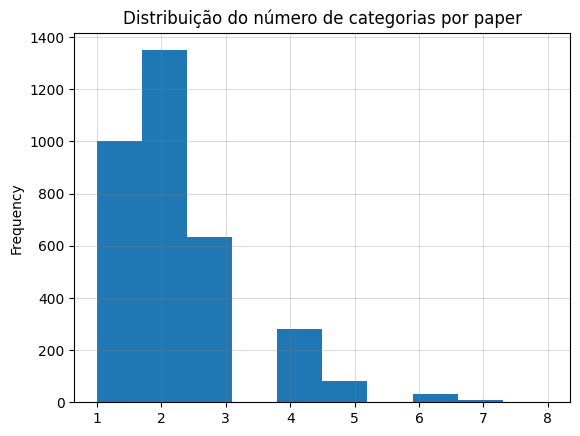

In [45]:
arxiv_df["n_categories"].plot(kind="hist")
plt.title("Distribuição do número de categorias por paper")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")
plt.show()

### Seaborn: a opção elegante para publicações.

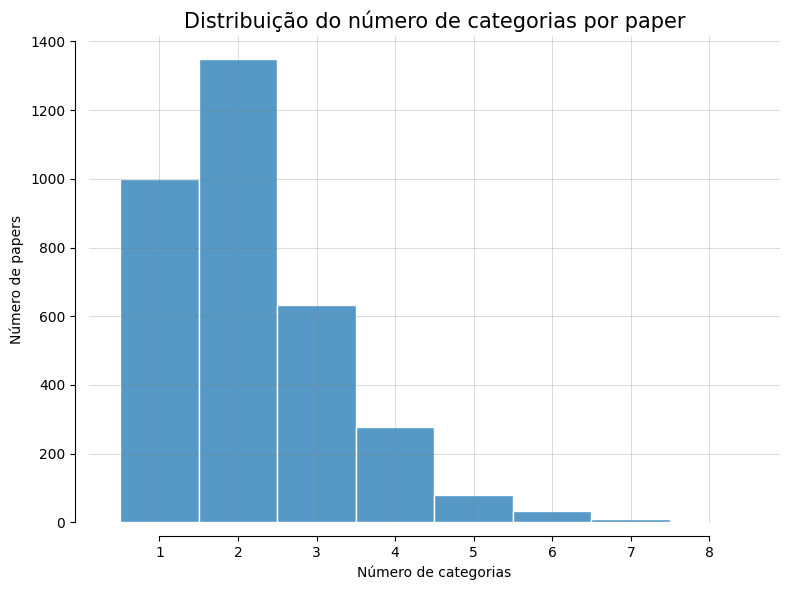

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=arxiv_df,
    x="n_categories",
    discrete=True,
    ax=ax,
    edgecolor="white",
)

ax.set_title("Distribuição do número de categorias por paper", fontsize=15)
ax.set(
    xlabel="Número de categorias",
    ylabel="Número de papers",
)
ax.grid(True, alpha=0.4, linewidth=0.5, color="grey")


sns.despine(ax=ax, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

### Histogramas são 'manipuláveis'

### 15 bins

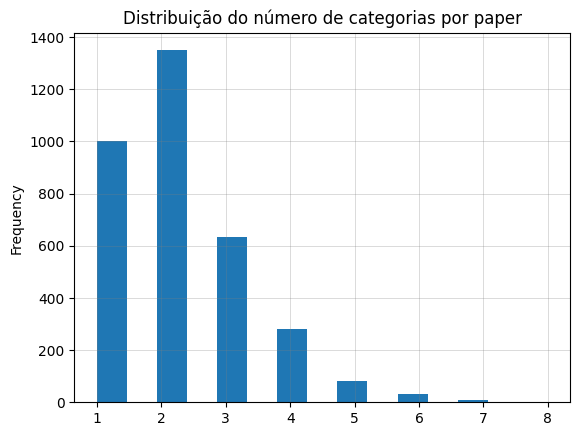

In [47]:
arxiv_df["n_categories"].plot(kind="hist", bins=15)
plt.title("Distribuição do número de categorias por paper")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")
plt.show()

### 12 bins

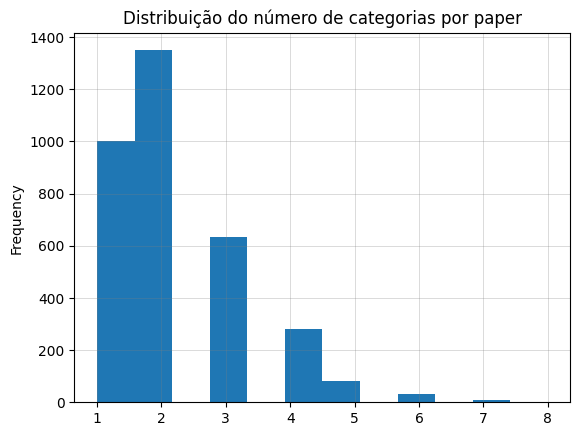

In [48]:
arxiv_df["n_categories"].plot(kind="hist", bins=12)
plt.title("Distribuição do número de categorias por paper")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")
plt.show()

### 8 bins

In [ ]:
arxiv_df["n_categories"].plot(kind="hist", bins=8)
plt.title("Distribuição do número de categorias por paper")
plt.grid(True, alpha=0.4, linewidth=0.5, color="grey")
plt.show()

### Simulando uma distribuição normal com base nas estatísticas da coluna `n_categories`

In [16]:
rng = np.random.default_rng(seed=42)

normal_df = pd.DataFrame(
    {
        "value": rng.normal(
            loc=arxiv_df["n_categories"].mean(),
            scale=arxiv_df["n_categories"].std(ddof=1),
            size=len(arxiv_df),
        )
    }
)

normal_df.describe()

,value
count,3387.000000
mean,2.160591
std,1.113605
min,-1.877702
25%,1.423143
50%,2.186021
75%,2.892821
max,5.723942


## Uma distribuição normal como contraste visual

A distribuição normal é uma referência comum em estatística. Mas nem toda variável precisa se parecer com uma normal.

Aqui, vamos simular uma distribuição normal apenas como contraste visual.
A pergunta não é “nossos dados são normais?”.
A pergunta é:

> que forma nossos dados têm, e por que essa forma importa?

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.histplot(
    data=arxiv_df,
    x="n_categories",
    bins=30,
    ax=ax1,
    edgecolor="white",
)

ax1.set_title("Distribuição do número de categorias por paper", fontsize=15)
ax1.set(xlabel="Contagem", ylabel="Frequências")
ax1.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax1.set_axisbelow(True)

sns.histplot(
    data=normal_df,
    x="value",
    bins=30,
    ax=ax2,
    color="r",
    edgecolor="white",
)

ax2.set_title("Distribuição Normal", fontsize=15)
ax2.set(xlabel="Contagem", ylabel="Frequências")
ax2.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax2.set_axisbelow(True)

sns.despine(fig=fig, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

## ECDF

ECDF significa Empirical Cumulative Distribution Function.

Ele responde uma pergunta simples:

> qual proporção dos dados está abaixo ou igual a determinado valor?

Por exemplo, se no eixo x temos `n_categories = 2` e no eixo y temos 80%, isso significa que 80% dos papers têm até 2 categorias.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.ecdfplot(
    data=arxiv_df,
    x="n_categories",
    ax=ax,
    stat="percent",
)

ax.set_title("ECDF do número de categorias por paper", fontsize=15)
ax.set(
    xlabel="Número de categorias",
    ylabel="Percentual acumulado (%)",
)
ax.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax.set_axisbelow(True)

sns.despine(ax=ax, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

### Comparando `n_categories` com um ECDF de uma distribuição normal

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.ecdfplot(
    data=arxiv_df,
    x="n_categories",
    ax=ax1,
    color="b",
    stat="percent",
)

ax1.set_title("ECDF do número de categorias por paper", fontsize=15)
ax1.set(
    xlabel="Número de categorias",
    ylabel="Percentual acumulado (%)",
)
ax1.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax1.set_axisbelow(True)

sns.ecdfplot(
    data=normal_df,
    x="value",
    ax=ax2,
    color="r",
    stat="percent",
)

ax2.set_title("ECDF Normal", fontsize=15)
ax2.set(
    xlabel="Valores da Distribuição Normal",
    ylabel="Percentual acumulado (%)",
)
ax2.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax2.set_axisbelow(True)

sns.despine(fig=fig, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

## Distribuições normais com as mesmas estatísticas, mas com um número maior de 'data points'

In [20]:
rng = np.random.default_rng(seed=42)

normal_bigger_n = pd.DataFrame(
    {
        "value": rng.normal(
            loc=arxiv_df["n_categories"].mean(),
            scale=arxiv_df["n_categories"].std(ddof=1),
            size=100_000,
        )
    }
)

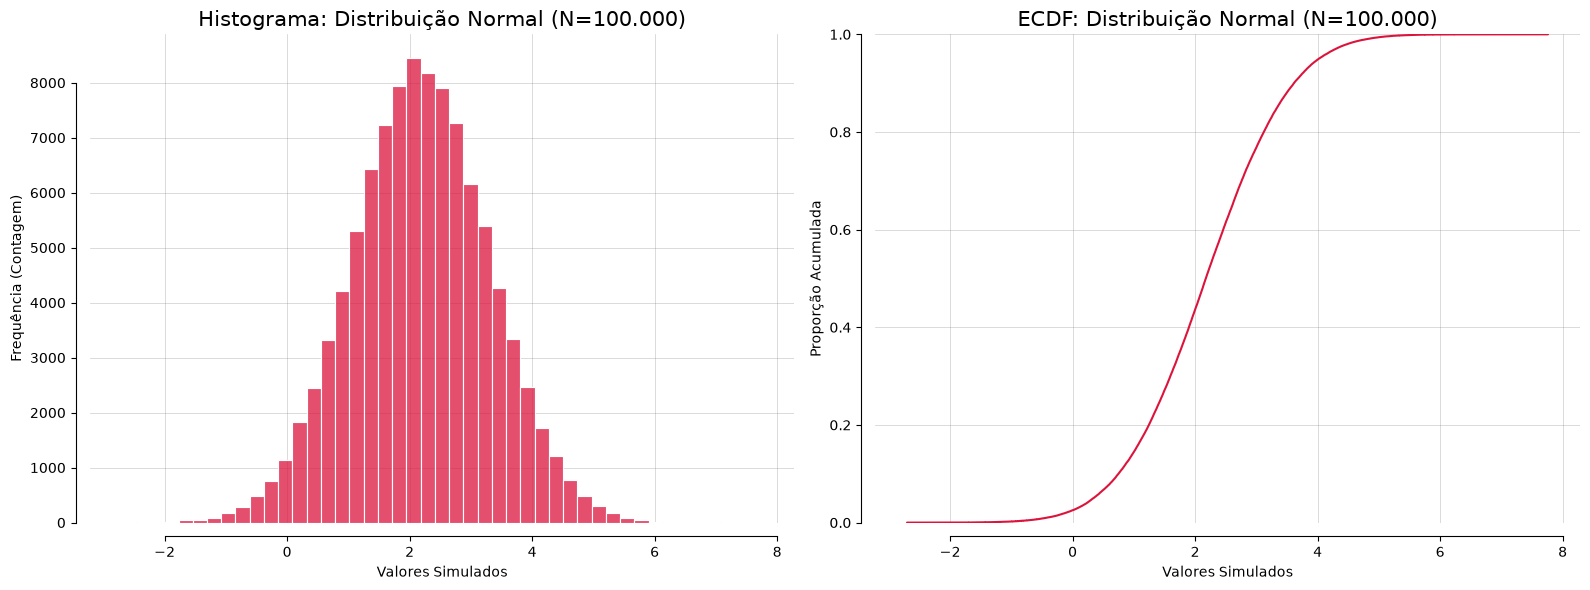

In [21]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.histplot(
    data=normal_bigger_n,
    x="value",
    bins=45,
    color="crimson",
    ax=ax1,
    edgecolor="white",
)

ax1.set_title("Histograma: Distribuição Normal (N=100.000)", fontsize=15)
ax1.set(xlabel="Valores Simulados", ylabel="Frequência (Contagem)")
ax1.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax1.set_axisbelow(True)

sns.ecdfplot(
    data=normal_bigger_n,
    x="value",
    ax=ax2,
    color="crimson",
)

ax2.set_title("ECDF: Distribuição Normal (N=100.000)", fontsize=15)
ax2.set(xlabel="Valores Simulados", ylabel="Proporção Acumulada")
ax2.grid(True, alpha=0.4, linewidth=0.5, color="grey")
ax2.set_axisbelow(True)

sns.despine(fig=fig, top=True, right=True, trim=True, offset=10)
plt.tight_layout()
plt.show()

# A partir daqui: material novo do Encontro 6

Como o mesmo padrão de análise será repetido para outras variáveis, vamos transformar o código em uma função.

In [22]:
def plot_hist_ecdf(
    dataframe,
    column,
    variable_label,
    bins=30,
    discrete=False,
):
    values = dataframe[column].dropna()
    mean_value = values.mean()
    median_value = values.median()

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 5))

    sns.histplot(
        data=dataframe,
        x=column,
        bins=bins,
        discrete=discrete,
        edgecolor="white",
        ax=ax1,
    )
    ax1.axvline(
        mean_value,
        linestyle="--",
        color="crimson",
        label=f"Média: {mean_value:.2f}",
    )
    ax1.axvline(
        median_value,
        linestyle="-",
        label=f"Mediana: {median_value:.2f}",
    )
    ax1.set_title(f"Histograma: {variable_label}", fontsize=14)
    ax1.set(xlabel=variable_label, ylabel="Número de observações")
    ax1.legend()

    sns.ecdfplot(x=values, stat="percent", ax=ax2)
    ax2.set_title(f"ECDF: {variable_label}", fontsize=14)
    ax2.set(
        xlabel=variable_label,
        ylabel="Percentual acumulado (%)",
    )

    for axis in (ax1, ax2):
        axis.grid(True, alpha=0.4, linewidth=0.5, color="grey")
        axis.set_axisbelow(True)

    sns.despine(fig=fig, top=True, right=True, trim=True, offset=10)
    plt.tight_layout()
    plt.show()

## Protocolo mínimo para uma variável numérica

Para começar a entender uma variável numérica, podemos combinar:

1. `.describe()`;
2. histograma;
3. ECDF.

O `.describe()` dá números.

O histograma mostra a forma geral.

O ECDF mostra a acumulação dos valores sem depender de bins.

Nenhum deles sozinho é suficiente.

Juntos, eles dão uma primeira leitura muito mais responsável.

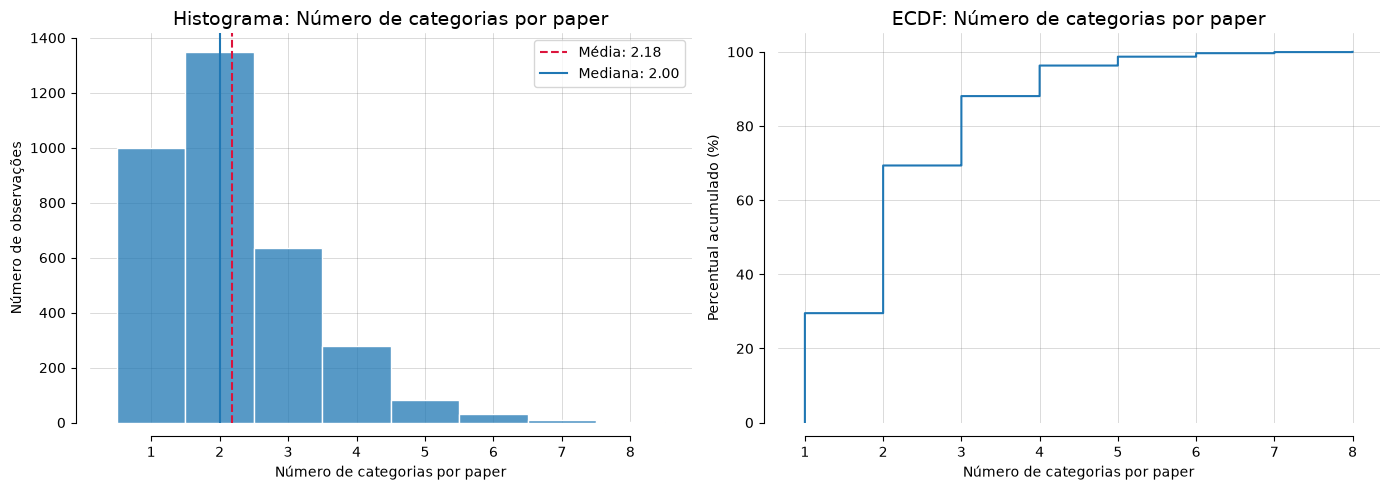

In [23]:
plot_hist_ecdf(
    dataframe=arxiv_df,
    column="n_categories",
    variable_label="Número de categorias por paper",
    discrete=True,
)

## Segunda variável: tamanho dos abstracts

`n_categories` era uma variável discreta pequena.

Agora vamos analisar `abstract_n_words`.

Essa variável é mais próxima do nosso interesse como linguistas e pesquisadores de texto, porque descreve uma propriedade textual: o tamanho do abstract. Antes de resumir a distribuição, verificamos se há valores ausentes.

In [24]:
print(
    f"Valores ausentes em abstract_n_words: "
    f"{arxiv_df['abstract_n_words'].isna().sum()}"
)

Valores ausentes em abstract_n_words: 0


In [25]:
sns.set_color_codes(palette="bright")

“Em dados de contagem, uma variância muito maior que a média chama atenção quando usamos a distribuição de Poisson como referência. Em comprimentos de texto, essa heterogeneidade também pode fazer parte do fenômeno que estamos estudando.”

In [26]:
arxiv_df["abstract_n_words"].describe()

count    3387.000000
mean      172.085326
std        47.876997
min        38.000000
25%       139.000000
50%       171.000000
75%       204.000000
max       310.000000
Name: abstract_n_words, dtype: float64

In [27]:
abstract_values = arxiv_df["abstract_n_words"]

abstract_mean = abstract_values.mean()
abstract_var = abstract_values.var(ddof=1)

print(f"Média dos abstracts: {abstract_mean:.2f}")
print(f"Variância dos abstracts: {abstract_var:.2f}")
print(f"Razão variância/média: {abstract_var / abstract_mean:.2f}")

Média dos abstracts: 172.09
Variância dos abstracts: 2292.21
Razão variância/média: 13.32


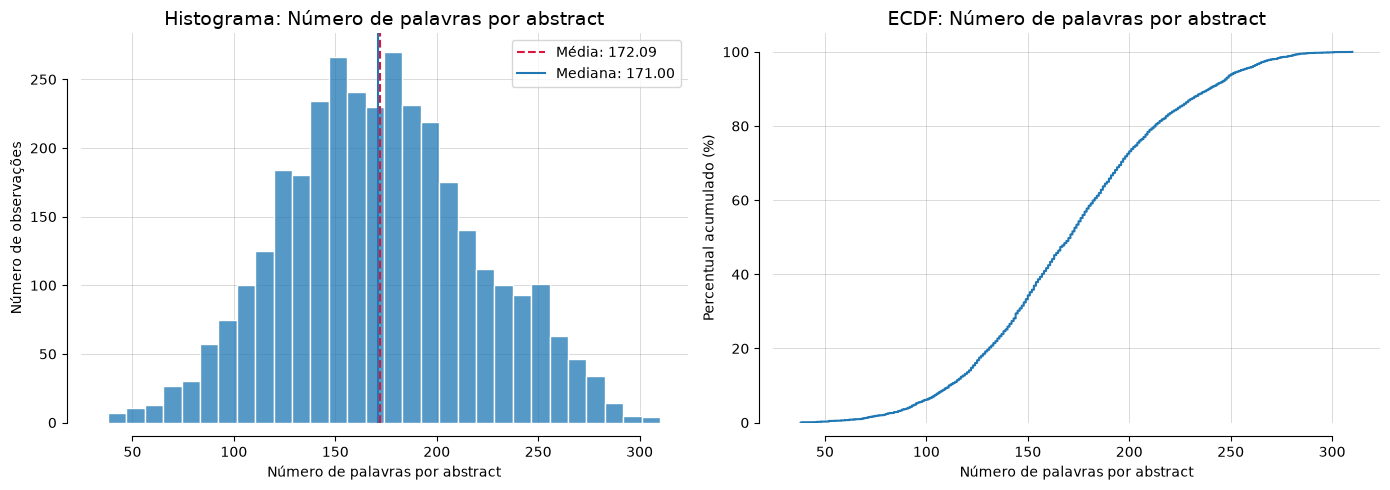

In [28]:
plot_hist_ecdf(
    dataframe=arxiv_df,
    column="abstract_n_words",
    variable_label="Número de palavras por abstract",
    bins=30,
    discrete=False,
)

### Q-Q Plot (Quantile-Quantile Plot): diagnóstico visual em relação à distribuição normal

O Q-Q plot compara os quantis observados com os quantis esperados de uma distribuição teórica — aqui, a normal.

**Como funciona?**
Ele plota os quantis da distribuição observada contra os quantis da distribuição teórica esperada.

**Como interpretar?**
- **Pontos próximos da reta:** indicam compatibilidade aproximada entre os quantis observados e os quantis teóricos.
- **Desvios sistemáticos:** curvatura, assimetria ou afastamento nas caudas mostram onde a distribuição observada difere da referência normal. O plot é um diagnóstico visual; ele não decide sozinho se um procedimento é adequado.

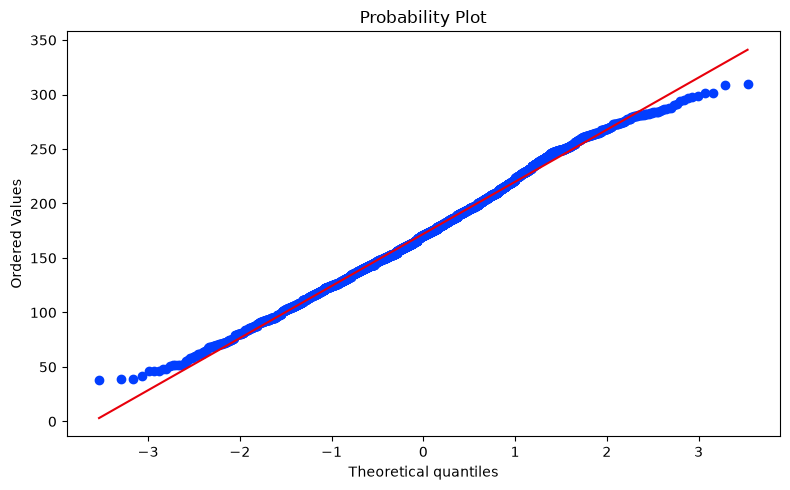

In [29]:
# Feioso
fig, ax = plt.subplots(figsize=(8, 5))

stats.probplot(
    arxiv_df["abstract_n_words"],
    dist="norm",
    plot=ax,
)

points, fit_line = ax.lines


plt.tight_layout()
plt.show()

In [ ]:
# Elegante: Seaborn

fig, ax = plt.subplots(figsize=(8, 5))

stats.probplot(
    arxiv_df["abstract_n_words"],
    dist="norm",
    plot=ax,
)

points, fit_line = ax.lines

points.set(
    markeredgecolor="white",
    markersize=8,
    alpha=0.4,
)

fit_line.set(
    color="crimson",
    linewidth=1.8,
    linestyle="--",
)

ax.set(
    xlabel="Theoretical Quantiles (Normal Dist.)",
    ylabel="Valores observados: palavras no abstract",
)

ax.set_title("Q-Q Plot: número de palavras por abstract", pad=10, fontsize=14)

ax.grid(alpha=0.4, linewidth=0.5, color="grey")
sns.despine(ax=ax, top=True, trim=True, offset=10)

plt.tight_layout()
plt.show()

### Comparando a distribuição simulada (Poisson) vs. a variável real

Para uma variável aleatória de Poisson, a esperança e a variância são exatamente iguais ao parâmetro da distribuição:

$$
E(Y) = Var(Y) = \lambda
$$

Ao comparar `abstract_n_words` com uma simulação de Poisson de mesma média, vemos que os dados reais variam muito mais do que essa referência simples de uma única taxa prevê. Isso mostra incompatibilidade com uma referência de Poisson homogênea, mas não constitui um diagnóstico formal de sobredispersão de um modelo ajustado. Para isso, seria necessário ajustar um modelo de contagem e examinar a variação condicional e os resíduos.

In [31]:
rng = np.random.default_rng(seed=42)

poisson_df = pd.DataFrame(
    {
        "abstract_n_words_poisson": rng.poisson(
            lam=abstract_mean,
            size=len(arxiv_df),
        )
    }
)

pd.concat(
    [
        abstract_values.describe().rename("real"),
        poisson_df["abstract_n_words_poisson"].describe().rename("poisson"),
    ],
    axis=1,
)


,real,poisson
count,3387.000000,3387.000000
mean,172.085326,171.697372
std,47.876997,12.847104
min,38.000000,127.000000
25%,139.000000,163.000000
50%,171.000000,172.000000
75%,204.000000,180.000000
max,310.000000,220.000000


In [32]:
print(
    f"Variance abstract_n_words: "
    f"{arxiv_df['abstract_n_words'].var(ddof=1):.2f}"
)
print(
    f"Variance Poisson reference: "
    f"{poisson_df['abstract_n_words_poisson'].var(ddof=1):.2f}"
)

Variance abstract_n_words: 2292.21
Variance Poisson reference: 165.05


## Quais áreas aparecem no dataset?

Uma primeira pergunta categórica é:

> quais áreas aparecem no nosso recorte?


In [33]:
arxiv_df["primary_category"].value_counts()

primary_category
stat.ML    1000
cs.LG       799
stat.AP     649
cs.CL       493
cs.AI       172
cs.HC       114
cs.CY        77
cs.IR        71
cs.DL        12
Name: count, dtype: int64

### Normalised Shannon Entropy

Primeiro calculamos a entropia de Shannon bruta:

$$
H = -\sum_{i=1}^{n} p_i \ln(p_i)
$$

Com $n$ categorias observadas, a entropia máxima é $H_{max} = \ln(n)$. A entropia normalizada divide uma pela outra:

$$
H_{norm} = \frac{H}{H_{max}}
$$

- `0` significa que todas as observações pertencem a uma categoria.
- Valores próximos de `1` indicam uma distribuição relativamente equilibrada entre as categorias incluídas.
- Valores intermediários indicam concentração crescente em algumas categorias.

A normalização depende do número de categorias incluídas. Valores ausentes precisam ser tratados deliberadamente; abaixo, `dropna=False` os mantém como uma categoria. O resultado descreve este recorte curado do arXiv e não deve ser interpretado automaticamente como a diversidade disciplinar natural de todo o arXiv.

In [34]:
def normalised_shannon_entropy(series):
    proportions = series.value_counts(normalize=True, dropna=False)
    proportions = proportions[proportions > 0]

    if len(proportions) <= 1:
        return 0.0

    entropy = stats.entropy(proportions, base=np.e)
    max_entropy = np.log(len(proportions))
    return entropy / max_entropy

In [35]:
norm_entropy_categories = normalised_shannon_entropy(
    arxiv_df["primary_category"]
)

print(f"Normalised Entropy for categories: {norm_entropy_categories:.4f}")

Normalised Entropy for categories: 0.7967


In [36]:
categorical_entropy = (
    arxiv_df.select_dtypes(include=["category"])
    .apply(normalised_shannon_entropy)
    .sort_values()
)

categorical_entropy

decade              0.000000
primary_category    0.796710
category_label      0.796710
top_level           0.999502
top_level_label     0.999502
dtype: float64